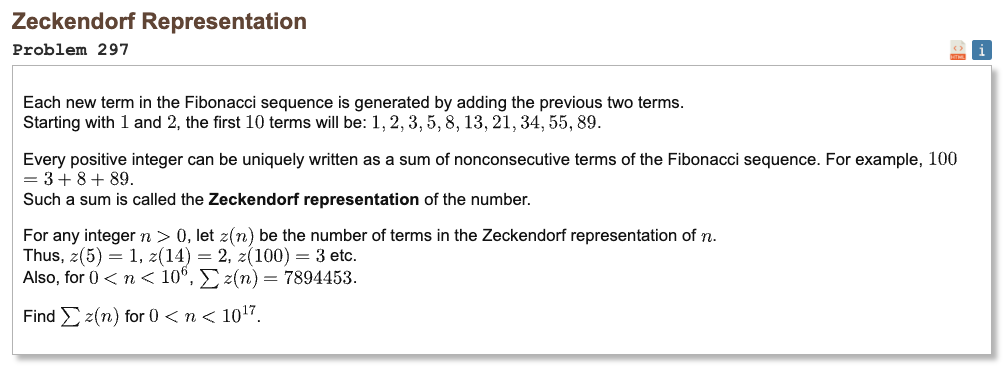

## Initial approach

* build the fibonacci style list only up to the largest value below the target
* use a classic counting pattern: for all numbers below a given fibonacci threshold,
* the total number of used terms can be accumulated from earlier thresholds
* when breaking the target interval, always take the largest allowed fibonacci value first
* once that largest value is chosen, every remaining number in the tail gets one extra used term from that choice
* the numbers in the remaining tail also contribute their own zeckendorf term counts, so recurse on the leftover part
* this turns a huge summation into a very short recursion over the fibonacci thresholds
* the whole solution is fast because the target only needs around a hundred fibonacci values

In [1]:
def solve(limit):
    fib = [1, 2]
    while fib[-1] <= limit:
        fib.append(fib[-1] + fib[-2])

    total = [0, 0]
    for i in range(2, len(fib)):
        total.append(total[i - 1] + total[i - 2] + fib[i - 2])

    def prefix_sum(n):
        if n <= 0:
            return 0
        if n == 1:
            return 1

        k = 0
        while fib[k + 1] <= n:
            k += 1

        remainder = n - fib[k]
        return total[k] + remainder + 1 + prefix_sum(remainder)

    return prefix_sum(limit - 1)

In [2]:
%%time
result = solve(10**17)
print("Result:", result)

Result: 2214442440679707514
CPU times: user 167 μs, sys: 7 μs, total: 174 μs
Wall time: 172 μs
